# 01 · Аудит даних — CCT-20 + порожній супlement

**Що це.** Ноутбук-ревізія даних для проєкту «спуск затвора на рись» (Raspberry
Pi 5). Він **нічого не рахує заново** і **не приймає рішень** — лише читає вже
заморожені маніфести (`data/manifests/*.jsonl`) та готові результати аудиту
(`results/data_audit/*.json`, `results/ablations/*.json`) і показує їх людині:
розподіли класів / локацій / сплітів, витік між train і cis-val, порожній
супlement і shortcut-probe, геометрію кадрів, вибір вхідного розміру та галерею
репрезентативних кадрів.

**Дисципліна тесту (DESIGN §5.4).** Тут допустимі лише механічні лічильники
маніфестів. Жодних метрик моделі на `cis_test`/`trans_test`, жодних передбачень.
Галерея бере кадри тільки з `train`, `cis_val_clean`, `trans_val` і супlementу —
тестові спліти не відкриваємо навіть на перегляд.

**Джерело істини.** Числа приходять з артефактів Gate B (пройдено 2026-07-15,
43/43). Ноутбук наприкінці перевіряє, що артефакт усе ще «passed» — якщо колись
регресне, комірка впаде.


In [1]:
# --- середовище та шляхи -------------------------------------------------- #
%matplotlib inline
import json, sys, subprocess, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display


def find_proj(start: Path) -> Path:
    """Каталог final_project = той, де лежать DESIGN.md та results/data_audit."""
    for p in [start, *start.parents]:
        if (p / "DESIGN.md").exists() and (p / "results" / "data_audit").exists():
            return p
    raise RuntimeError("не знайдено корінь final_project від " + str(start))


PROJ = find_proj(Path.cwd().resolve())
sys.path.insert(0, str(PROJ / "src"))  # щоб import wildlife_trigger.* працював

DATA = PROJ / "data"
MANIFESTS = DATA / "manifests"
AUDIT = PROJ / "results" / "data_audit"
ABL = PROJ / "results" / "ablations"
CCT_IMG = DATA / "raw" / "extracted" / "eccv_18_all_images_sm"
SUP_IMG = DATA / "images" / "empty_supplement"
ANN = DATA / "raw" / "extracted" / "eccv_18_annotation_files"


def load_json(p):
    return json.loads(Path(p).read_text())


def load_jsonl(p):
    return [json.loads(x) for x in Path(p).read_text().splitlines() if x.strip()]


def git_rev():
    try:
        return (
            subprocess.check_output(
                ["git", "rev-parse", "--short", "HEAD"], cwd=str(PROJ)
            )
            .decode()
            .strip()
        )
    except Exception:
        return "unknown"


COMMIT = git_rev()
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "font.size": 10,
        "axes.grid": True,
        "grid.alpha": 0.30,
        "axes.axisbelow": True,
    }
)


def caption(ax, extra=""):
    """Кожен графік підписуємо сплітом/кількістю/комітом (DESIGN §17)."""
    txt = f"CCT-20 · data-audit · commit {COMMIT}"
    if extra:
        txt = extra + " · " + txt
    ax.annotate(
        txt,
        xy=(1.0, -0.16),
        xycoords="axes fraction",
        ha="right",
        va="top",
        fontsize=7,
        color="#666",
    )


print("final_project:", PROJ)
print("commit       :", COMMIT)
print(
    "runtime      :",
    "python",
    platform.python_version(),
    "| numpy",
    np.__version__,
    "| pandas",
    pd.__version__,
    "| matplotlib",
    matplotlib.__version__,
)


final_project: /home/deploy/efficientml/efficient-ml-set/final_project
commit       : 7a659b8
runtime      : python 3.12.3 | numpy 2.4.4 | pandas 3.0.3 | matplotlib 3.11.1


In [2]:
# --- заморожені артефакти аудиту ------------------------------------------ #
gate = load_json(AUDIT / "gate_b.json")
manifest_report = load_json(AUDIT / "manifest_report.json")
dims = load_json(AUDIT / "dimension_report.json")
probe = load_json(AUDIT / "shortcut_probe.json")
supp = load_json(AUDIT / "empty_supplement_selection.json")
input_cost = load_json(ABL / "input_cost.json")

CLASSES = [c["name"] for c in manifest_report["classes"]]
SELECTABLE = {c["name"]: c["selectable_target"] for c in manifest_report["classes"]}
SPLITS = ["train", "cis_val", "cis_test", "trans_val", "trans_test"]
DECISION_SPLITS = ["train", "cis_val_clean", "trans_val"]  # що реально дивимось

n_checks = len(gate["checks"])
n_failed = len(gate["failed_checks"])
print(f"Gate B: passed={gate['passed']}  checks={n_checks}  failed={n_failed}")
print("16 класів (порядок = зростання CCT category_id):")
print("  " + ", ".join(f"{i}:{c}" for i, c in enumerate(CLASSES)))
print("не-цілі (не можна вибрати як target):",
      [c for c in CLASSES if not SELECTABLE[c]])


Gate B: passed=True  checks=43  failed=0
16 класів (порядок = зростання CCT category_id):
  0:opossum, 1:raccoon, 2:squirrel, 3:bobcat, 4:skunk, 5:dog, 6:coyote, 7:rabbit, 8:bird, 9:cat, 10:badger, 11:empty, 12:car, 13:deer, 14:fox, 15:rodent
не-цілі (не можна вибрати як target): ['empty', 'car']


## 1. Спліти, класи, локації

Офіційний розкрій CCT-20: п'ять сплітів. `cis_*` — ті самі 10 локацій, розділені
в часі (тому між train і cis-val є витік послідовностей — див. §2). `trans_*` —
**інші** локації (доменний зсув: інші камери, ракурси, тло). Саме `trans_val` —
наш чесний проксі до продакшену, тому рись на ньому — головна ціль.


In [3]:
# Таблиця сплітів: зображення / послідовності / локації / рись / мульти-лейбл
rows = []
for s in SPLITS:
    d = manifest_report["splits"][s]
    rows.append(
        {
            "split": s,
            "images": d["images"],
            "sequences": d["sequences"],
            "locations": len(d["locations"]),
            "bobcat_img": d["bobcat_images"],
            "multi_label": d["multi_class_images"],
        }
    )
# + очищений cis_val_clean (те, на чому калібруємо й вибираємо моделі)
lk = manifest_report["leakage"]
rows.insert(
    2,
    {
        "split": "cis_val_clean",
        "images": lk["cis_val_clean"]["images"],
        "sequences": "—",
        "locations": 10,
        "bobcat_img": lk["cis_val_clean"]["bobcat_images"],
        "multi_label": 0,
    },
)
split_df = pd.DataFrame(rows).set_index("split")
print("Таблиця 1a (DESIGN §17.1) — розкрій даних:")
display(split_df)
print("Всього зображень:", manifest_report["total_images"],
      "| усі лічильники сходяться:", manifest_report["all_counts_reconcile"])


Таблиця 1a (DESIGN §17.1) — розкрій даних:


,images,sequences,locations,bobcat_img,multi_label
split,,,,,
train,13553,5527,10,786,7
cis_val,3484,1421,10,154,0
cis_val_clean,3214,—,10,144,0
cis_test,15827,6424,10,897,1
trans_val,1725,589,1,793,61
trans_test,23275,8982,9,2338,9


Всього зображень: 57864 | усі лічильники сходяться: True


In [4]:
# Матриця клас × спліт (механічні лічильники, DESIGN §5.4 дозволяє)
cd = {s: dict(gate["class_distribution"][s]) for s in SPLITS}
mat = pd.DataFrame({s: [cd[s].get(c, 0) for c in CLASSES] for s in SPLITS}, index=CLASSES)
print("Таблиця 1b — кількість зображень на клас у кожному спліті:")
display(mat)

# Ключове спостереження: у train немає жодного 'empty'
print(
    "\nУ офіційному train кадрів 'empty':",
    cd["train"].get("empty", 0),
    "→ порожній клас навчається ВИКЛЮЧНО на доданих 5000 кадрах (супlement, §3).",
)


Таблиця 1b — кількість зображень на клас у кожному спліті:


,train,cis_val,cis_test,trans_val,trans_test
opossum,2726,490,4524,444,5505
raccoon,1027,169,1047,129,5469
squirrel,1250,222,659,0,1051
bobcat,786,154,897,793,2338
skunk,229,43,194,63,328
dog,820,139,845,96,888
coyote,1409,285,1326,51,2249
rabbit,2443,493,1758,70,846
bird,484,114,574,7,224
cat,1287,192,1632,72,1418



У офіційному train кадрів 'empty': 0 → порожній клас навчається ВИКЛЮЧНО на доданих 5000 кадрах (супlement, §3).


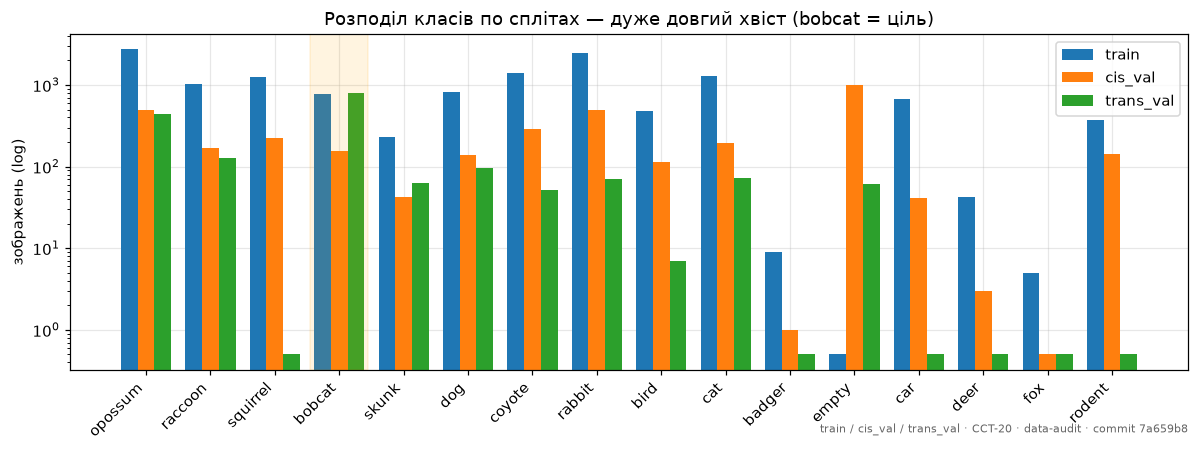

In [5]:
# Розподіл класів на трьох сплітах, які реально дивимось (log-шкала: розмах 5..5505)
plot_splits = ["train", "cis_val", "trans_val"]
x = np.arange(len(CLASSES))
w = 0.26
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, s in enumerate(plot_splits):
    vals = [cd[s].get(c, 0) for c in CLASSES]
    ax.bar(x + (i - 1) * w, np.maximum(vals, 0.5), w, label=s)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_ylabel("зображень (log)")
ax.set_title("Розподіл класів по сплітах — дуже довгий хвіст (bobcat = ціль)")
# підсвітити рись
ax.axvspan(x[CLASSES.index("bobcat")] - 0.45, x[CLASSES.index("bobcat")] + 0.45,
           color="orange", alpha=0.12)
ax.legend()
caption(ax, "train / cis_val / trans_val")
plt.tight_layout()
plt.show()


cis локації (train/cis_val/cis_test спільні): [33, 38, 43, 51, 61, 88, 90, 108, 115, 120]
trans_val локації: [125] | trans_test локації: [0, 7, 28, 40, 46, 78, 100, 105, 130]
перетин cis ∩ trans: [] → порожній: домени рознесені за локаціями (DESIGN §5.2).


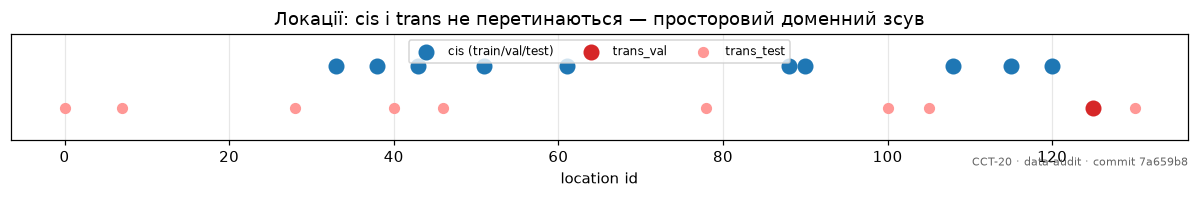

In [6]:
# Локації: cis (спільні 10) vs trans (інші). Це — доменний зсув у одній картинці.
loc = {s: [int(k) for k, _ in gate["location_distribution"][s]] for s in SPLITS}
cis_locs = sorted(set(loc["train"]) | set(loc["cis_val"]) | set(loc["cis_test"]))
tval = sorted(loc["trans_val"])
ttest = sorted(loc["trans_test"])
print("cis локації (train/cis_val/cis_test спільні):", cis_locs)
print("trans_val локації:", tval, "| trans_test локації:", ttest)
print("перетин cis ∩ trans:", sorted(set(cis_locs) & (set(tval) | set(ttest))),
      "→ порожній: домени рознесені за локаціями (DESIGN §5.2).")

fig, ax = plt.subplots(figsize=(11, 1.9))
ax.scatter(cis_locs, [1] * len(cis_locs), s=90, label="cis (train/val/test)", color="#1f77b4")
ax.scatter(tval, [0.6] * len(tval), s=90, label="trans_val", color="#d62728")
ax.scatter(ttest, [0.6] * len(ttest), s=40, label="trans_test", color="#ff9896")
ax.set_yticks([])
ax.set_ylim(0.3, 1.3)
ax.set_xlabel("location id")
ax.set_title("Локації: cis і trans не перетинаються — просторовий доменний зсув")
ax.legend(loc="upper center", ncol=3, fontsize=8)
caption(ax)
plt.tight_layout()
plt.show()


## 2. Витік train ↔ cis-val і чому ми беремо `cis_val_clean`

Офіційний `cis_val` ділить `seq_id` із train. Кадри однієї послідовності — майже
дублікати (burst камери-пастки), тож запам'ятований тренувальний кадр «впізнає»
свого близнюка на валідації й завищує метрику. `cis_val_clean` прибирає **кожну**
послідовність, що перетинається з train. Каліброка (C3) і вибір моделей ідуть
саме по ньому.


,cis_val (офіц.),перетин із train,cis_val_clean
метрика,,,
зображень,3484,270,3214
seq,1421,224,—
bobcat,154,10,144


перетин збігається з очікуваним фінгерпринтом: True | clean збігається: True


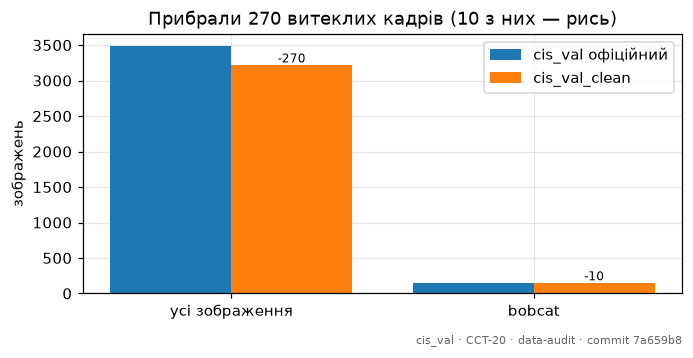

In [7]:
# Таблиця витоку (DESIGN §17.2)
of = manifest_report["splits"]["cis_val"]
ov = lk["observed_overlap"]
cl = lk["cis_val_clean"]
leak_df = pd.DataFrame(
    [
        {"метрика": "зображень", "cis_val (офіц.)": of["images"],
         "перетин із train": ov["cis_val_images"], "cis_val_clean": cl["images"]},
        {"метрика": "seq", "cis_val (офіц.)": of["sequences"],
         "перетин із train": ov["sequences"], "cis_val_clean": "—"},
        {"метрика": "bobcat", "cis_val (офіц.)": of["bobcat_images"],
         "перетин із train": ov["bobcat_images"], "cis_val_clean": cl["bobcat_images"]},
    ]
).set_index("метрика")
display(leak_df)
print("перетин збігається з очікуваним фінгерпринтом:", lk["overlap_reconciles"],
      "| clean збігається:", lk["clean_reconciles"])

fig, ax = plt.subplots(figsize=(6.4, 3.4))
cats = ["усі зображення", "bobcat"]
off = [of["images"], of["bobcat_images"]]
cln = [cl["images"], cl["bobcat_images"]]
xx = np.arange(len(cats))
ax.bar(xx - 0.2, off, 0.4, label="cis_val офіційний")
ax.bar(xx + 0.2, cln, 0.4, label="cis_val_clean")
for i, (a, b) in enumerate(zip(off, cln)):
    ax.annotate(f"-{a-b}", (i + 0.2, b), ha="center", va="bottom", fontsize=8)
ax.set_xticks(xx)
ax.set_xticklabels(cats)
ax.set_ylabel("зображень")
ax.set_title("Прибрали 270 витеклих кадрів (10 з них — рись)")
ax.legend()
caption(ax, "cis_val")
plt.tight_layout()
plt.show()


## 3. Порожній супlement і shortcut-probe

У офіційному train немає класу `empty` (див. §1), тож фон «нічого не сталося» ми
додаємо окремо: 5000 порожніх кадрів CCT (той самий домен, інші локації), відібрані
детерміновано (seed 42) і **повністю рознесені** з CCT-20 за id / seq / локацією.
Ризик — що модель вивчить не «порожньо чи ні», а «CCT це чи супlement» (артефакт
кодека/камери). Тому ганяємо shortcut-probe: класифікатор на самому декодованому
RGB-тензорі. Якщо він близький до випадкового — сорочкового сигналу нема.


Порожній супlement (cct_empty_train_v1):
  відібрано 5000 з 121828 кандидатів (seed 42)
  локацій 106, макс. частка однієї локації 4.42%
  рознесеність із CCT-20: {'locations_overlapping_cct20': 0, 'image_ids_overlapping_cct20': 0, 'seq_ids_overlapping_cct20': 0}


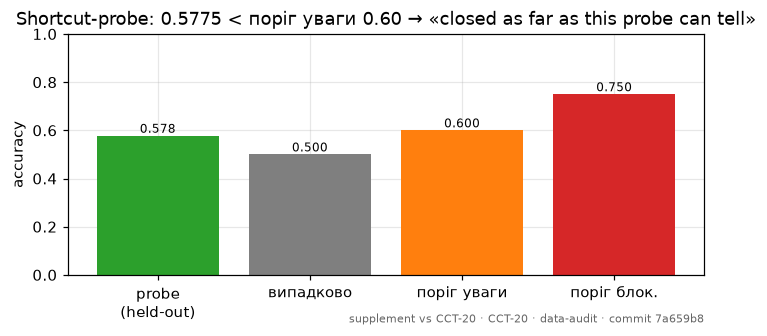

blocks_training: False — Rule 3 makes the supplement location-disjoint, so backgrounds genuinely differ and that confound is unavoidable (DESIGN §5.2). This probe cannot tell 'different camera' from 'different encoder'; a positive result says investigate, not which cause.


In [8]:
print("Порожній супlement (cct_empty_train_v1):")
print(f"  відібрано {supp['selected']} з {supp['candidates_available']} кандидатів "
      f"(seed {supp['seed']})")
print(f"  локацій {supp['locations_used']}, макс. частка однієї локації "
      f"{supp['max_location_share']:.2%}")
print("  рознесеність із CCT-20:", supp["disjointness"])

fig, ax = plt.subplots(figsize=(6.6, 3.2))
bars = {
    "probe\n(held-out)": probe["held_out_accuracy"],
    "випадково": probe["chance"],
    "поріг уваги": probe["thresholds"]["attention"],
    "поріг блок.": probe["thresholds"]["blocking"],
}
colors = ["#2ca02c", "#7f7f7f", "#ff7f0e", "#d62728"]
ax.bar(list(bars), list(bars.values()), color=colors)
for i, v in enumerate(bars.values()):
    ax.annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel("accuracy")
ax.set_title("Shortcut-probe: {:.4f} < поріг уваги 0.60 → «{}»".format(
    probe["held_out_accuracy"], probe["verdict"]))
caption(ax, "supplement vs CCT-20")
plt.tight_layout()
plt.show()
print("blocks_training:", probe["blocks_training"], "—", probe["caveat"])


## 4. Геометрія кадру: що ми **насправді** декодуємо

Анотації записують оригінальну геометрію (домінантно 2048×1494). Але пайплайн
споживає архів `_sm`, у якому довга сторона обрізана до 1024, тож реальний кадр —
**1024×747** (91.4% усіх). Це — фундамент для вибору вхідного розміру (§5) і для
міркувань про decode на Pi.


Виміряно з JPEG-заголовків _sm (не з анотацій): 57864 зображень
домінантний кадр: 1024x747 (91.44%) | довга сторона ≤ 1024


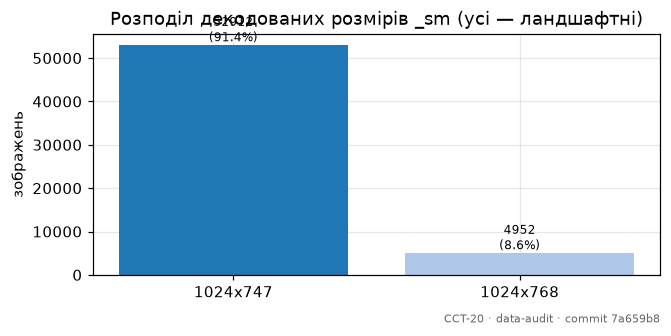

Оригінал (declared) vs декодований (_sm): 2048×1494 → 1024×747 (кожна сторона /2).


In [9]:
top = dims["top_sizes"]
print("Виміряно з JPEG-заголовків _sm (не з анотацій):",
      dims["total_images_measured"], "зображень")
print("домінантний кадр:", dims["dominant"],
      f"({dims['dominant_share']:.2%})", "| довга сторона ≤", dims["max_long_side"])

fig, ax = plt.subplots(figsize=(6.2, 3.2))
labels = list(top)
vals = list(top.values())
ax.bar(labels, vals, color=["#1f77b4", "#aec7e8"])
for i, v in enumerate(vals):
    ax.annotate(f"{v}\n({v/dims['total_images_measured']:.1%})",
                (i, v), ha="center", va="bottom", fontsize=8)
ax.set_ylabel("зображень")
ax.set_title("Розподіл декодованих розмірів _sm (усі — ландшафтні)")
caption(ax)
plt.tight_layout()
plt.show()
print("Оригінал (declared) vs декодований (_sm): 2048×1494 → 1024×747 "
      "(кожна сторона /2).")


## 5. Вибір вхідного розміру: 256×192 проти 224×224

Заморожено C1a (2026-07-16) на реальних валід-даних. Ідея: при майже однаковому
бюджеті пікселів/MAC квадрат 224×224 витрачає ~чверть тензора на сірі поля (кадр
ландшафтний і не влазить у квадрат), а 256×192 майже точно повторює домінантний
аспект → у мережу потрапляє значно більше «тварини».


Таблиця 3 (DESIGN §17.3) — вартість входу:


,tensor_px,MACs,real_px (cis_val_clean),utilisation
input,,,,
256x192,49152,293402624,47910.0,97.47%
224x224,50176,299514752,36546.0,72.83%


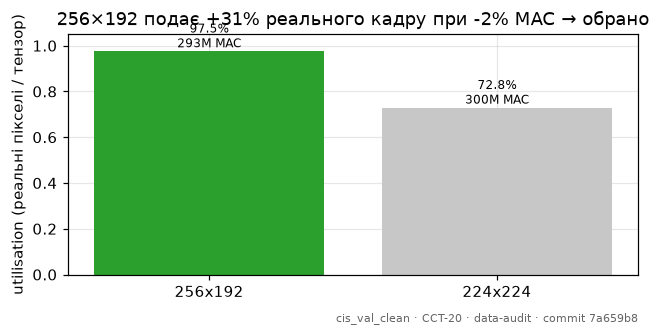

In [10]:
rows = []
for r in input_cost["rows"]:
    u = r["utilisation"]["cis_val_clean"]
    rows.append(
        {
            "input": r["input"],
            "tensor_px": r["tensor_pixels"],
            "MACs": r["macs"],
            "real_px (cis_val_clean)": round(u["mean_real_pixels"], 0),
            "utilisation": f"{u['mean_utilisation']:.2%}",
        }
    )
cost_df = pd.DataFrame(rows).set_index("input")
print("Таблиця 3 (DESIGN §17.3) — вартість входу:")
display(cost_df)

fig, ax = plt.subplots(figsize=(6.0, 3.2))
inp = [r["input"] for r in input_cost["rows"]]
util = [r["utilisation"]["cis_val_clean"]["mean_utilisation"] for r in input_cost["rows"]]
macs = [r["macs"] / 1e6 for r in input_cost["rows"]]
colors = ["#2ca02c" if v == max(util) else "#c7c7c7" for v in util]
ax.bar(inp, util, color=colors)
for i, (v, m) in enumerate(zip(util, macs)):
    ax.annotate(f"{v:.1%}\n{m:.0f}M MAC", (i, v), ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("utilisation (реальні пікселі / тензор)")
ax.set_title("256×192 подає +31% реального кадру при -2% MAC → обрано")
caption(ax, "cis_val_clean")
plt.tight_layout()
plt.show()


## 6. Репрезентативні кадри

Галерея для ока: денний RGB, нічний IR (ЧБ), порожній кадр CCT vs порожній
супlement (візуальна перевірка до §3), рись, «маленька тварина» (з рамкою з train
анотацій — показує, чому не можна центр-кроп), і дві наявні форми кадру. Вибір
детермінований (сорт за image_id, перший, що проходить евристику). Кадри — тільки
з train / cis_val_clean / trans_val / супlементу.

*Зображення © відповідні rights_holder, CCT-20 через LILA (CDLA-Permissive);*
*показані у зменшеному вигляді лише для аудиту.*


In [11]:
# Індекси маніфестів + мапа bbox з train-анотацій (COCO) для «малої тварини»
def index_manifest(name):
    return {r["file_name"]: r for r in load_jsonl(MANIFESTS / f"{name}.jsonl")}


train_idx = index_manifest("train")
cvc_idx = index_manifest("cis_val_clean")
tval_idx = index_manifest("trans_val")
supp_idx = index_manifest("cct_empty_train_v1")


def img_path(rec):
    """Супlement лежить окремо; решта — у архіві _sm."""
    p = SUP_IMG / rec["file_name"]
    return p if p.exists() else CCT_IMG / rec["file_name"]


def dims_of(rec):
    """Декодований розмір; маніфест супlementу вживає downsized_* замість observed_*."""
    for w, h in (("observed_width", "observed_height"),
                 ("downsized_width", "downsized_height"),
                 ("declared_width", "declared_height")):
        if w in rec and h in rec:
            return rec[w], rec[h]
    return "?", "?"


def load_rgb(rec, max_side=512):
    import cv2

    bgr = cv2.imread(str(img_path(rec)), cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("decode failed: " + rec["file_name"])
    rgb = bgr[:, :, ::-1]
    h, w = rgb.shape[:2]
    s = min(1.0, max_side / max(h, w))
    if s < 1.0:
        rgb = cv2.resize(rgb, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
    return np.ascontiguousarray(rgb)


def colourfulness(rec):
    """Середній розмах каналів: ~0 → ЧБ/IR, велике → яскравий день."""
    import cv2

    bgr = cv2.imread(str(img_path(rec)), cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    small = cv2.resize(bgr, (128, 96)).astype(np.int16)
    return float((small.max(2) - small.min(2)).mean())


ANIMALS = [c for c in CLASSES if SELECTABLE[c]]  # 14 тварин (без empty/car)


def pick(index, label=None, want="rgb", scan=140, keep=None):
    """Детермінований вибір: сортуємо за image_id, беремо перший за евристикою."""
    items = sorted(index.values(), key=lambda r: r["image_id"])
    cand = [
        r
        for r in items
        if (label is None or label in r["labels"]) and (keep is None or keep(r))
    ][:scan]
    if want == "rgb":
        best = max(cand, key=lambda r: (colourfulness(r) or -1))
    elif want == "ir":
        scored = [(colourfulness(r), r) for r in cand]
        scored = [(c, r) for c, r in scored if c is not None]
        best = min(scored, key=lambda t: t[0])[1]
    else:
        best = cand[0]
    return best


# train COCO анотації → bbox (в оригінальних пікселях declared_*)
tann = load_json(ANN / "train_annotations.json")
catmap = {c["id"]: c["name"] for c in tann["categories"]}
bbox_by_id = {}
for a in tann["annotations"]:
    if a.get("bbox"):
        bbox_by_id.setdefault(a["image_id"], []).append(
            (catmap.get(a["category_id"], "?"), a["bbox"])
        )
print("train зображень з bbox:", len(bbox_by_id))


train зображень з bbox: 12099


«мала тварина»: рись, частка кадру під рамкою = 1.05% (найменша у train = 0.236%) → центр-кроп міг би її зрізати (DESIGN §5.5).


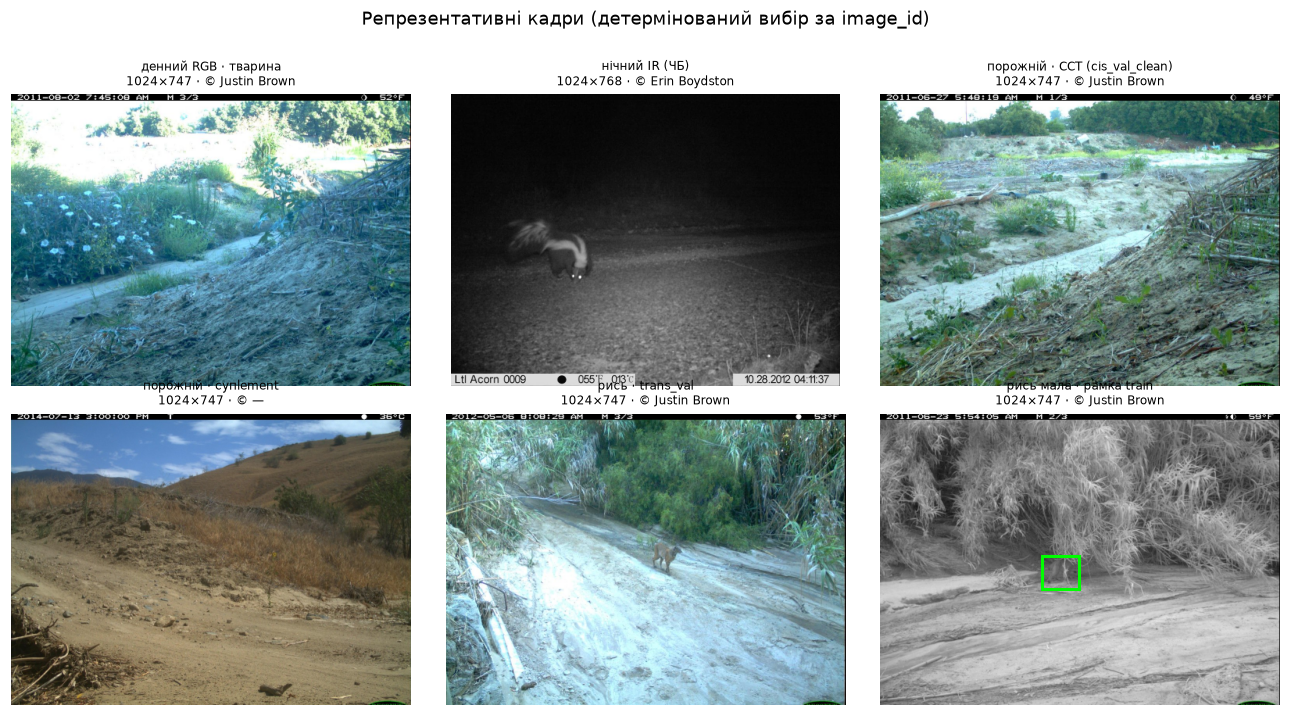

In [12]:
# Обрати «малу тварину»: серед train-рисей — найменша частка кадру під рамкою
def area_frac(rec):
    boxes = bbox_by_id.get(rec["image_id"], [])
    boxes = [b for cat, b in boxes if cat == rec["primary_label"]]
    if not boxes:
        return None
    W = rec["declared_width"] * rec["declared_height"]
    return min((b[2] * b[3]) / W for b in boxes)


bob_train = [r for r in train_idx.values()
             if r["primary_label"] == "bobcat" and area_frac(r) is not None]
bob_train.sort(key=area_frac)
# найменша рамка, що ще помітна оком (≥1% кадру): показує «не кропати», лишаючись видимою
visible_small = [r for r in bob_train if area_frac(r) >= 0.01]
small_rec = visible_small[0] if visible_small else bob_train[0]
print("«мала тварина»: рись, частка кадру під рамкою =",
      f"{area_frac(small_rec):.2%}",
      f"(найменша у train = {area_frac(bob_train[0]):.3%})",
      "→ центр-кроп міг би її зрізати (DESIGN §5.5).")

is_animal = lambda r: r["primary_label"] in ANIMALS
samples = [
    ("денний RGB · тварина", pick(train_idx, want="rgb", keep=is_animal)),
    ("нічний IR (ЧБ)", pick(train_idx, want="ir")),
    ("порожній · CCT (cis_val_clean)", pick(cvc_idx, label="empty", want="any")),
    ("порожній · супlement", pick(supp_idx, want="any")),
    ("рись · trans_val", pick(tval_idx, label="bobcat", want="rgb")),
    ("рись мала · рамка train", small_rec),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6.4))
for ax, (title, rec) in zip(axes.ravel(), samples):
    rgb = load_rgb(rec)
    ax.imshow(rgb)
    if title.startswith("рись мала"):
        H, W = rec["declared_height"], rec["declared_width"]
        sx, sy = rgb.shape[1] / W, rgb.shape[0] / H
        for cat, b in bbox_by_id.get(rec["image_id"], []):
            if cat == "bobcat":
                ax.add_patch(Rectangle((b[0] * sx, b[1] * sy), b[2] * sx, b[3] * sy,
                             fill=False, edgecolor="lime", lw=2))
    w, h = dims_of(rec)
    ax.set_title(f"{title}\n{w}×{h} · © {rec.get('rights_holder', '—')}", fontsize=8)
    ax.axis("off")
fig.suptitle("Репрезентативні кадри (детермінований вибір за image_id)", y=1.01)
plt.tight_layout()
plt.show()


### 6б. Летербокс: що бачить мережа

Той самий код препроцесингу, що й C++/кеш (`wildlife_trigger.data.preprocess`).
Показуємо домінантний ландшафтний кадр і трохи вищий 1024×768 у 256×192 та, для
контрасту, у 224×224 — видно, скільки квадрат витрачає на сірі поля. *У CCT-20
немає портретних кадрів — усі пастки знімають ландшафтно; нижче — дві наявні
форми.*


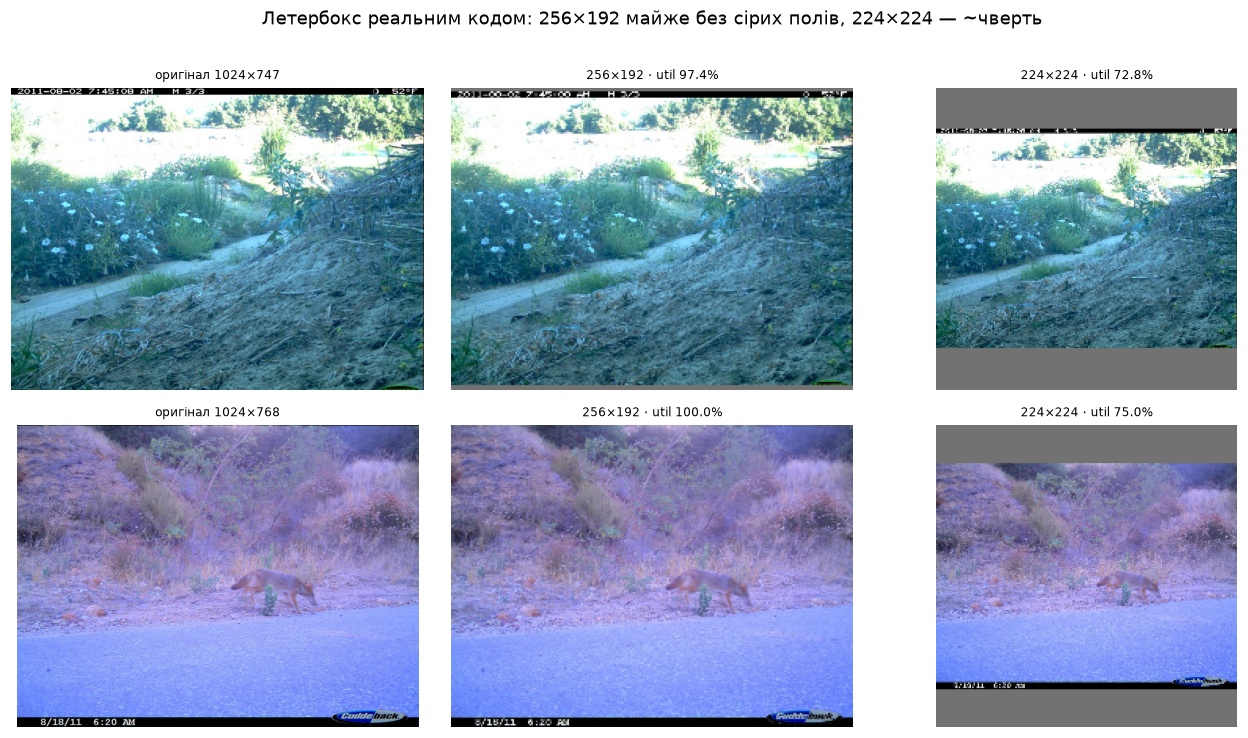

In [13]:
from wildlife_trigger.data.preprocess import PreprocessConfig, decode, letterbox_bgr

cfg_core = PreprocessConfig(width=256, height=192)   # рішення
cfg_sq = PreprocessConfig(width=224, height=224)     # відхилена альтернатива

# два кадри різної форми: домінантний 1024x747 (util 97.4%, DESIGN §5.5) та вищий 1024x768
def pick_shape(h):
    pool = [r for r in train_idx.values()
            if r.get("observed_height") == h and r["primary_label"] in ANIMALS]
    pool = pool or [r for r in train_idx.values() if r.get("observed_height") == h]
    pool.sort(key=lambda r: r["image_id"])
    return max(pool[:120], key=lambda r: (colourfulness(r) or -1))


wide = pick_shape(747)    # домінантний ландшафтний кадр
taller = pick_shape(768)  # трохи вищий (4:3), майже точний збіг з 256×192

fig, axes = plt.subplots(2, 3, figsize=(12, 6.6))
for row, rec in enumerate([wide, taller]):
    bgr = decode(str(img_path(rec)))
    orig = bgr[:, :, ::-1]
    lb_core, info_c = letterbox_bgr(bgr, cfg_core)
    lb_sq, info_s = letterbox_bgr(bgr, cfg_sq)
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"оригінал {rec['observed_width']}×{rec['observed_height']}",
                           fontsize=8)
    axes[row, 1].imshow(lb_core)
    axes[row, 1].set_title(f"256×192 · util {info_c.pixel_utilisation():.1%}", fontsize=8)
    axes[row, 2].imshow(lb_sq)
    axes[row, 2].set_title(f"224×224 · util {info_s.pixel_utilisation():.1%}", fontsize=8)
    for a in axes[row]:
        a.axis("off")
fig.suptitle("Летербокс реальним кодом: 256×192 майже без сірих полів, 224×224 — ~чверть",
             y=1.01)
plt.tight_layout()
plt.show()


## 7. Мульти-лейбл і недоступні цілі

Модель — одно-лейбловий softmax, але в анотаціях є кадри з кількома класами.
Правило (DESIGN §5.4.1): 7 мульти-лейбл train-кадрів виключені з CE; у метриках
присутності цілі всі лейбли лишаються. Окремо — валід-підтримка на ціль: `deer`
і `fox` мають 0 позитивів, `badger` — рівно 1, тож усі три записані як недоступні
цілі з `null`-порогами.


Мульти-лейбл кадрів по сплітах (очікувано 7/0/1/61/9): [7, 0, 1, 61, 9]

Валід-підтримка на ціль (cis_val_clean + trans_val):


,target?,val_images,val_sequences,статус
class,,,,
bobcat,рись (ГОЛОВНА),937,315,ok
opossum,так,918,306,ok
rabbit,так,462,157,ok
coyote,так,309,119,ok
raccoon,так,294,98,ok
cat,так,261,87,ok
dog,так,223,75,ok
squirrel,так,205,69,ok
rodent,так,135,45,ok


/tmp/ipykernel_117656/3561678706.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=45, ha="right")


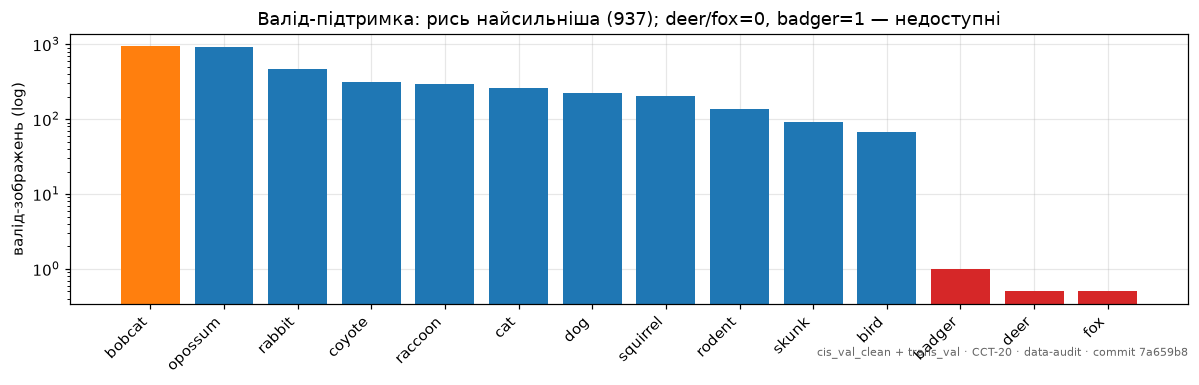

In [14]:
ml = {s: manifest_report["splits"][s]["multi_class_images"] for s in SPLITS}
print("Мульти-лейбл кадрів по сплітах (очікувано 7/0/1/61/9):",
      [ml[s] for s in SPLITS])

sup = gate["validation_support"]  # cis_val_clean + trans_val
animals = [c for c in CLASSES if SELECTABLE[c]]  # 14 тварин (без empty/car)
sup_df = pd.DataFrame(
    [
        {
            "class": c,
            "target?": "рись (ГОЛОВНА)" if c == "bobcat" else "так",
            "val_images": sup[c]["images"],
            "val_sequences": sup[c]["sequences"],
            "статус": "НЕДОСТУПНА (null-поріг)"
            if sup[c]["images"] <= 1 and c in ("deer", "fox", "badger")
            else "ok",
        }
        for c in animals
    ]
).set_index("class").sort_values("val_images", ascending=False)
print("\nВалід-підтримка на ціль (cis_val_clean + trans_val):")
display(sup_df)

fig, ax = plt.subplots(figsize=(11, 3.6))
order = sup_df.index.tolist()
vals = sup_df["val_images"].values
cols = ["#d62728" if v <= 1 else ("#ff7f0e" if c == "bobcat" else "#1f77b4")
        for c, v in zip(order, vals)]
ax.bar(order, np.maximum(vals, 0.5), color=cols)
ax.set_yscale("log")
ax.set_ylabel("валід-зображень (log)")
ax.set_title("Валід-підтримка: рись найсильніша (937); deer/fox=0, badger=1 — недоступні")
ax.set_xticklabels(order, rotation=45, ha="right")
caption(ax, "cis_val_clean + trans_val")
plt.tight_layout()
plt.show()


## 8. Підсумок Gate B

Ноутбук нічого не перевіряв заново — він показав уже пройдений гейт. Остання
комірка стверджує, що артефакт усе ще «passed» і 0 провалів (інакше — падає), та
друкує фінгерпринт завантаження (source hashes): якщо колись числа зміняться,
перше питання — чи не перевидав LILA дані.


In [15]:
assert gate["passed"] is True, "Gate B artefact regressed: passed != True"
assert not gate["failed_checks"], f"Gate B has failures: {gate['failed_checks']}"
print(f"GATE B PASSED — {n_checks} перевірок, {n_failed} провалів.")
print("\nФінгерпринт завантаження (DESIGN §5.1):")
for k, v in gate["source_hashes"].items():
    print(f"  {k}: {v[:16]}…")
print("\n✅ Ноутбук виконано без помилок. Артефакти читані, рішень не приймалось,",
      "тестові лейбли не відкривались.")


GATE B PASSED — 43 перевірок, 0 провалів.

Фінгерпринт завантаження (DESIGN §5.1):
  eccv_18_annotations.tar.gz: e31d0162d411fb03…
  eccv_18_all_images_sm.tar.gz: 50d0e46d4f42c489…
  caltech_camera_traps.json.zip: 976bd9bc9380df7a…

✅ Ноутбук виконано без помилок. Артефакти читані, рішень не приймалось, тестові лейбли не відкривались.


## Як ми це робили / що пробували

- **Читаємо, а не рахуємо.** Усі числа — з `results/data_audit/*.json` та
  `results/ablations/*.json` (заморожені Gate B / C1a). Ноутбук — вітрина для
  ревізії, тому один код рахує гейт (`wildlife_trigger.data.audit`), а тут його
  лише показуємо. Дублювати логіку гейта в ноутбуці — рецепт розбіжності.
- **Дисципліна тесту.** Свідомо не рендеримо і не рахуємо нічого з
  `cis_test`/`trans_test` (DESIGN §5.4) — навіть кадри галереї беремо тільки з
  train / cis_val_clean / trans_val / супlементу.
- **Детермінований вибір кадрів.** Сорт за `image_id` + евристика (розмах каналів
  для день/IR, частка кадру під bbox для «малої тварини») — щоб перезапуск давав
  ті самі кадри, а не випадкові.
- **Реальний препроцесинг у демо летербокса.** Використали `preprocess.py`
  напряму (той самий шлях, що й C++/кеш), щоб «що бачить мережа» було справжнім,
  а не намальованим.
- **Що вирішили не робити.** Не малювали портретних кадрів (їх у CCT-20 нема) —
  показали дві реальні форми і сказали про це прямо, замість вигадувати приклад.
- **Дрібне, на що витратили час:** геометрію брали з JPEG-заголовків `_sm`, а не
  з анотацій (анотації описують оригінал 2048×1494, а мережа їсть 1024×747);
  bbox з COCO — в оригінальних пікселях, тож масштабували на `observed/declared`,
  щоб рамка лягла на декодований кадр.
